[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/angeld222/CasalsFranco/blob/main/entornos_complejos/notebook_3_metodos_aproximados.ipynb)

# **Métodos de Diferencias Temporales con CliffWalking**

**Autores:** Gloria Casals y Ángel Franco

Introducción al Entorno y Métodos TD
El entorno CliffWlaking se diseñó específicamente en el libro de Sutton & Barto para demostrar que SARSA y Q-Learning son distintos. Aprovecharemos nuestros experimentos para comprobarlo en nuestro estudio.

El objetivo que se define en este entorno es ir del punto A al punto B evitando un precipicio.

La teoría nos dice que:

Q-Learning (Off-Policy): Aprenderá el camino óptimo. Bordeará el precipicio porque asume que en el futuro actuará de forma perfecta (greedy), aunque durante el entrenamiento se caiga a menudo por la exploración.
SARSA (On-Policy): Aprenderá el camino seguro. Se alejará del precipicio porque tiene en cuenta que su propia política ( ϵ=0.15 ) puede cometer errores aleatorios y empujarlo al vacío.

In [ ]:
# Clonamos el repositorio
!git clone https://github.com/AngelD222/CasalsFranco.git

Cloning into 'CasalsFranco'...
remote: Enumerating objects: 536, done.
remote: Counting objects: 100% (271/271), done.
remote: Compressing objects: 100% (240/240), done.
remote: Total 536 (delta 59), reused 1 (delta 1), pack-reused 265 (from 1)
Receiving objects: 100% (536/536), 132.82 KiB | 6.64 MiB/s, done.
Resolving deltas: 100% (156/156), done.


In [ ]:
import os
import sys
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

repo_name = 'CasalsFranco/entornos_complejos'

# Añadimos la ruta al sistema
if f'/content/{repo_name}' not in sys.path:
    sys.path.append(f'/content/{repo_name}')

print("Archivos en el directorio:")
!ls /content/{repo_name}

from src.utils.seeder import set_seed, make_env
from src.utils.trainer import train_agent
from src.agents.sarsa import AgentSARSA
from src.agents.q_learning import AgentQLearning
from src.utils.plotter import plot_episode_rewards, plot_episode_lengths, plot_win_rate, plot_multiple_seeds_rewards, moving_average


SEMILLA = 2908
set_seed(SEMILLA)

# Configuración específica para CliffWalking
# CliffWalking es un entorno simple, 500-1000 episodios sobran.
EPISODIOS_CW = 500
# Importante: Epsilon NO debe decaer a 0 para ver la diferencia de "seguridad"
# Si epsilon es 0, ambos harían lo mismo. Mantenemos 10% de ruido.
hp_cw = {'gamma': 1.0, 'epsilon': 0.1, 'alpha': 0.5}


Archivos en el directorio:
README.md  src
Usando dispositivo: cpu


## **Ejecución en entorno CliffWalking**

In [ ]:
# Configuración específica para CliffWalking
# CliffWalking es un entorno simple, 500-1000 episodios sobran.
EPISODIOS_CW = 500
# Importante: Epsilon NO debe decaer a 0 para ver la diferencia de "seguridad"
# Si epsilon es 0, ambos harían lo mismo. Mantenemos 10% de ruido.
hp_cw = {'gamma': 1.0, 'epsilon': 0.1, 'alpha': 0.5}

# 1. SARSA en CliffWalking
env_cw_sarsa = make_env("CliffWalking-v1", seed=SEMILLA)
agent_cw_sarsa = AgentSARSA(env_cw_sarsa, hp_cw)

print("\nEntrenando SARSA en CliffWalking...")
# decay_rate=0.0 para mantener epsilon constante en 0.1
stats_cw_sarsa = train_agent(
    env_cw_sarsa,
    agent_cw_sarsa,
    EPISODIOS_CW,
    initial_eps=0.1,
    final_eps=0.1,
    decay_rate=0.0
)

# 2. Q-Learning en CliffWalking
env_cw_q = make_env("CliffWalking-v1", seed=SEMILLA)
agent_cw_q = AgentQLearning(env_cw_q, hp_cw)

print("Entrenando Q-Learning en CliffWalking...")
stats_cw_q = train_agent(
    env_cw_q,
    agent_cw_q,
    EPISODIOS_CW,
    initial_eps=0.1,
    final_eps=0.1,
    decay_rate=0.0
)


Entrenando SARSA en CliffWalking...


Entrenando agente: 100%|██████████| 500/500 [00:00<00:00, 898.28it/s] 


Entrenando Q-Learning en CliffWalking...


Entrenando agente: 100%|██████████| 500/500 [00:00<00:00, 918.30it/s] 


### **Visualización**

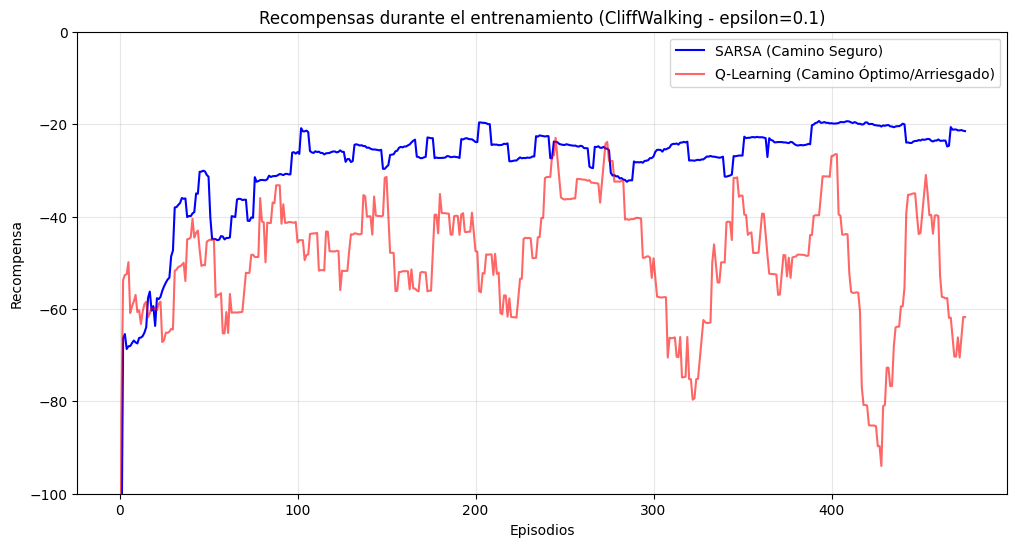

In [ ]:
# Graficamos los resultados (Media móvil pequeña porque son pocos episodios)
plt.figure(figsize=(12, 6))
plt.plot(moving_average(stats_cw_sarsa["episode_rewards"], 25), label='SARSA (Camino Seguro)', color='blue')
plt.plot(moving_average(stats_cw_q["episode_rewards"], 25), label='Q-Learning (Camino Óptimo/Arriesgado)', color='red', alpha=0.6)
plt.title("Recompensas durante el entrenamiento (CliffWalking - epsilon=0.1)")
plt.xlabel("Episodios")
plt.ylabel("Recompensa")
plt.legend()
plt.ylim(-100, 0) # Limitamos el eje Y para ver mejor la zona interesante
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Verificamos si es un diccionario o un array para sumarlo correctamente
def obtener_suma_q(agente):
    # Intentamos obtener la tabla, a veces se llama Q o q_table
    tabla = getattr(agente, 'q_table', None) or getattr(agente, 'Q', None)

    if tabla is None:
        return "No se encontró la Q-Table (verifica el nombre del atributo)"

    if isinstance(tabla, dict):
        return sum(tabla.values()) # Si es diccionario
    else:
        return np.sum(tabla) # Si es array numpy

print(f"Suma valores Q - SARSA: {obtener_suma_q(agent_cw_sarsa)}")
print(f"Suma valores Q - Q-Learning: {obtener_suma_q(agent_cw_q)}")

Suma valores Q - SARSA: [ -454.81393183  -642.44956204 -1305.81435983  -538.13681279]
Suma valores Q - Q-Learning: [ -311.46750057  -378.89439314 -1345.47129969  -318.6007864 ]


In [ ]:
def imprimir_camino_cliff(agente, env_name="CliffWalking-v1"):
    """
    Imprime una representación visual del camino aprendido.
    C = Cliff (Precipicio), G = Goal (Meta), S = Start, . = Camino seguro, X = Paso del agente
    """
    env = make_env(env_name, seed=SEMILLA)
    obs, _ = env.reset()

    # Grid de 4x12 típico de CliffWalking
    grid = [['.' for _ in range(12)] for _ in range(4)]
    # Marcamos el precipicio
    for i in range(1, 11): grid[3][i] = 'C'
    grid[3][0] = 'S'
    grid[3][11] = 'G'

    terminated = False
    truncated = False
    steps = 0
    total_reward = 0

    # Ejecutamos una partida voraz (sin exploración)
    agente_epsilon_orig = agente.epsilon
    agente.epsilon = 0.0 # Apagar exploración para ver lo aprendido

    current_obs = obs
    # Convertimos obs a coordenadas (row, col) si es un entero
    # En CliffWalking: row = obs // 12, col = obs % 12
    r, c = current_obs // 12, current_obs % 12
    grid[r][c] = 'S'

    while not (terminated or truncated) and steps < 20:
        action = agente.get_action(current_obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)

        # Marcar camino
        r, c = next_obs // 12, next_obs % 12
        if grid[r][c] != 'G' and grid[r][c] != 'C':
            grid[r][c] = 'X' # X marca el paso

        total_reward += reward
        current_obs = next_obs
        steps += 1

    agente.epsilon = agente_epsilon_orig # Restaurar epsilon

    # Imprimir Grid
    print(f"--- Camino del Agente ({agente.__class__.__name__}) ---")
    print(f"Recompensa Total: {total_reward}")
    for row in grid:
        print(" ".join(row))
    print("\n")

# Ejecuta esto para ver la diferencia real:
imprimir_camino_cliff(agent_cw_sarsa)
imprimir_camino_cliff(agent_cw_q)


--- Camino del Agente (AgentSARSA) ---
Recompensa Total: -17
X X X X X X X X X X X X
X . . . . . . . . . . X
X . . . . . . . . . . X
S C C C C C C C C C C G


--- Camino del Agente (AgentQLearning) ---
Recompensa Total: -13
. . . . . . . . . . . .
. . . . . . . . . . . .
X X X X X X X X X X X X
S C C C C C C C C C C G




### **Conclusiones del Estudio**

1. **En Blackjack:** La diferencia es sutil porque el entorno es muy estocástico. Ambos convergen a estrategias similares, aunque Q-Learning teóricamente encuentra la estrategia óptima más rápido al ignorar la exploración.
    
2. **En CliffWalking:** La diferencia es drástica.
    * **Q-Learning** aprende el camino óptimo (longitud 13 pasos, recompensa -13) pero sufre castigos enormes (-100, -80...) durante el entrenamiento cada vez que explora hacia el precipicio.
    * **SARSA** aprende un camino subóptimo pero más seguro (longitud ~15-17 pasos), evitando el borde para que la exploración ($\epsilon=0.1$) no lo mate.

Esto demuestra que **SARSA** es preferible en entornos donde los fallos durante el entrenamiento son costosos o peligrosos (robots reales), mientras que **Q-Learning** es mejor en simulaciones donde podemos permitirnos fallar para encontrar la política perfecta.